# CrackSAM v1 — SAM2 + LoRA for Crack & Drywall Segmentation

**Goal:** Replace CLIPSeg with SAM2-base fine-tuned via LoRA adapters.  
Uses the same dataset / splits / prompts / evaluation as `crackclip_v3`.  

**Key differences from CrackCLIP:**
- SAM2 ViT-B image encoder (much stronger dense-prediction backbone)
- LoRA on attention layers (rank-16) — lighter than bottleneck adapters
- No text conditioning — SAM is prompt-based, we auto-generate point prompts from GT during training
- At inference: grid-point prompting (no GT needed)
- Same BCE+Dice loss, same metrics, same evaluation pipeline

In [1]:
subprocess.run([
    "pip", "install", "-q",
    "git+https://github.com/facebookresearch/sam2.git",
    "albumentations", "opencv-python-headless",
    "pandas", "matplotlib",
], check=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 7.7 MB/s eta 0:00:00


CompletedProcess(args=['pip', 'install', '-q', 'git+https://github.com/facebookresearch/sam2.git', 'albumentations', 'opencv-python-headless', 'pandas', 'matplotlib'], returncode=0)

In [ ]:
import sys, os

sys.path.append("/kaggle/input/datasets/uknowmerun/src-code/src")

RUN_NAME = "cracksam_v1"

# SAM2 model

SAM_CHECKPOINT = "/kaggle/input/models/metaresearch/segment-anything-2/pytorch/sam2-hiera-base-plus/1/sam2_hiera_base_plus.pt"  # adjust path
SAM_CONFIG = "sam2_hiera_b+.yaml"  # model config name

PROCESSED_ROOT = "/kaggle/input/datasets/uknowmerun/dataset/processed"
SPLITS_JSON = "/kaggle/input/datasets/uknowmerun/dataset/processed/splits.json"
PROMPTS_CSV = "/kaggle/input/datasets/uknowmerun/dataset/processed/prompts.csv"

IMAGE_SIZE = (1024, 1024)  # SAM native resolution

# training config
EPOCHS = 30
BATCH_SIZE = 4  # SAM is larger, reduce batch
ACCUMULATION_STEPS = 4  # effective batch = 16
PATIENCE = 12
SEED = 42

# learning rates
LR_DECODER = 5e-4  # SAM mask decoder (lightweight)
LR_LORA = 1e-4  # LoRA params in encoder

# LoRA config
LORA_RANK = 16
LORA_ALPHA = 32
LORA_LAYERS = "all"  # apply to all attention layers

# loss
BCE_WEIGHT = 0.5
DICE_WEIGHT = 0.5

# output paths
CKPT_DIR = f"/kaggle/working//checkpoints/{RUN_NAME}"
PRED_DIR = f"/kaggle/working/predictions/{RUN_NAME}"
VIZ_DIR = f"/kaggle/working/visualisations/{RUN_NAME}"
METRICS_DIR = "/kaggle/working/metrics"

for d in [CKPT_DIR, PRED_DIR, VIZ_DIR, METRICS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Config OK")
print(f"  Image size   : {IMAGE_SIZE}")
print(f"  Epochs       : {EPOCHS}")
print(f"  LoRA rank    : {LORA_RANK}")
print(f"  LR decoder   : {LR_DECODER}")
print(f"  LR LoRA      : {LR_LORA}")

Config OK
  Image size   : (1024, 1024)
  Epochs       : 30
  LoRA rank    : 16
  LR decoder   : 0.0005
  LR LoRA      : 0.0001


In [ ]:
import json, random, math
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print("Imports OK")

Device: cuda
Imports OK


In [ ]:
with open(SPLITS_JSON) as f:
    splits = json.load(f)

prompts_df = pd.read_csv(PROMPTS_CSV)

print(f"Splits  seed={splits['seed']}")
for ds_name in ["drywall", "cracks"]:
    s = splits[ds_name]
    print(
        f"  {ds_name:10s}  train={len(s['train'])}  val={len(s['val'])}  test={len(s['test'])}"
    )
print(f"Prompts  {len(prompts_df)} rows")

Splits  seed=42
  drywall     train=172  val=36  test=38
  cracks      train=778  val=166  test=168
Prompts  1358 rows


In [ ]:
# SAM Dataset


class SAMCrackDataset(Dataset):
    """
    Dataset for SAM fine-tuning on crack/drywall segmentation.
    Returns image, mask, and point prompts sampled from GT.
    """

    def __init__(
        self,
        processed_root,
        splits_dict,
        prompts_df,
        split="train",
        image_size=(1024, 1024),
        num_points=5,
        neg_prob=0.3,
        transform=None,
    ):
        self.root = Path(processed_root)
        self.image_size = image_size
        self.num_points = num_points
        self.neg_prob = neg_prob
        self.split = split
        self.transform = transform

        # build sample list: (dataset_name, stem, prompt_text)
        self.samples = []

        # filter prompts_df by split to get per-sample prompt info
        split_df = prompts_df[prompts_df["split"] == split]

        if len(split_df) > 0:
            # use the CSV directly
            for _, row in split_df.iterrows():
                ds_name = row["dataset"]
                stem = row["stem"]
                prompt = row["positive_prompts"].split(";")[0]  # first prompt
                self.samples.append((ds_name, stem, prompt))
        else:
            # fallback: use splits_dict if prompts_df doesn't have this split
            for ds_name in ["drywall", "cracks"]:
                stems = splits_dict[ds_name][split]
                prompt = f"segment {ds_name} damage"
                for stem in stems:
                    self.samples.append((ds_name, stem, prompt))

        # pixel mean/std for SAM (ImageNet)
        self.pixel_mean = np.array([123.675, 116.28, 103.53], dtype=np.float32)
        self.pixel_std = np.array([58.395, 57.12, 57.375], dtype=np.float32)

    def __len__(self):
        return len(self.samples)

    def _sample_points(self, mask_np):
        """Sample point prompts from ground truth mask."""
        h, w = mask_np.shape
        pos_ys, pos_xs = np.where(mask_np > 0.5)
        neg_ys, neg_xs = np.where(mask_np < 0.5)

        points = []
        labels = []  # 1=positive, 0=negative

        n_pos = max(1, self.num_points // 2)
        n_neg = self.num_points - n_pos

        if len(pos_ys) > 0:
            idx = np.random.choice(
                len(pos_ys), size=min(n_pos, len(pos_ys)), replace=False
            )
            for i in idx:
                points.append([pos_xs[i], pos_ys[i]])
                labels.append(1)
        else:
            # no positive pixels sample from center
            points.append([w // 2, h // 2])
            labels.append(1)

        if len(neg_ys) > 0:
            idx = np.random.choice(
                len(neg_ys), size=min(n_neg, len(neg_ys)), replace=False
            )
            for i in idx:
                points.append([neg_xs[i], neg_ys[i]])
                labels.append(0)

        # pad to exactly num_points
        while len(points) < self.num_points:
            points.append([w // 2, h // 2])
            labels.append(-1)  # padding, will be ignored

        return np.array(points[: self.num_points], dtype=np.float32), np.array(
            labels[: self.num_points], dtype=np.float32
        )

    def __getitem__(self, idx):
        ds_name, stem, prompt = self.samples[idx]

        img_path = self.root / ds_name / "images" / f"{stem}.jpg"
        mask_path = self.root / ds_name / "masks" / f"{stem}.png"

        # read image (BGR - RGB) and mask
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        # resize to SAM input size
        image = cv2.resize(image, self.image_size, interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, self.image_size, interpolation=cv2.INTER_NEAREST)

        # normalize mask to [0, 1]
        mask = (mask > 127).astype(np.float32)

        # apply augmentations
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # sample point prompts from (possibly augmented) mask
        points, point_labels = self._sample_points(mask)

        # normalize image for SAM
        image = (image.astype(np.float32) - self.pixel_mean) / self.pixel_std
        image = torch.from_numpy(image).permute(2, 0, 1).float()  # (3, H, W)
        mask = torch.from_numpy(mask).unsqueeze(0).float()  # (1, H, W)

        return {
            "image": image,
            "mask": mask,
            "points": torch.from_numpy(points),
            "point_labels": torch.from_numpy(point_labels),
            "stem": stem,
            "prompt": prompt,
            "dataset": ds_name,
        }


def get_train_transform(size):
    return A.Compose(
        [
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
            A.GaussNoise(p=0.2),
            A.ElasticTransform(alpha=30, sigma=5, p=0.2),
        ]
    )


# build datasets
train_ds = SAMCrackDataset(
    PROCESSED_ROOT,
    splits,
    prompts_df,
    split="train",
    image_size=IMAGE_SIZE,
    num_points=5,
    neg_prob=0.3,
    transform=get_train_transform(IMAGE_SIZE),
)
val_ds = SAMCrackDataset(
    PROCESSED_ROOT,
    splits,
    prompts_df,
    split="val",
    image_size=IMAGE_SIZE,
    num_points=5,
)
test_ds = SAMCrackDataset(
    PROCESSED_ROOT,
    splits,
    prompts_df,
    split="test",
    image_size=IMAGE_SIZE,
    num_points=5,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

print(f"Train: {len(train_ds)} samples, {len(train_loader)} batches")
print(f"Val:   {len(val_ds)} samples, {len(val_loader)} batches")
print(f"Test:  {len(test_ds)} samples, {len(test_loader)} batches")

Train: 950 samples, 237 batches
Val:   202 samples, 51 batches
Test:  206 samples, 52 batches


In [ ]:
# LoRA Module + SAM with LoRA adapters


class LoRALinear(nn.Module):
    """Low-Rank Adaptation for a frozen linear layer."""

    def __init__(self, original_linear: nn.Linear, rank: int = 16, alpha: float = 32.0):
        super().__init__()
        self.original = original_linear
        in_features = original_linear.in_features
        out_features = original_linear.out_features

        self.rank = rank
        self.scale = alpha / rank

        # ── Fix: Get device and dtype from the original layer ──
        device = original_linear.weight.device
        dtype = original_linear.weight.dtype

        # ── Fix: Create LoRA layers on the correct device/dtype ──
        self.lora_A = nn.Linear(
            in_features, rank, bias=False, device=device, dtype=dtype
        )
        self.lora_B = nn.Linear(
            rank, out_features, bias=False, device=device, dtype=dtype
        )

        # init: A ~ kaiming, B = 0  →  starts as identity
        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)

        # freeze original
        for p in self.original.parameters():
            p.requires_grad = False

    def forward(self, x):
        return self.original(x) + self.lora_B(self.lora_A(x)) * self.scale


def inject_lora(model, rank=16, alpha=32.0, target_modules=None):
    """
    Walk through the model and replace Linear layers that match
    target_modules with LoRA-wrapped versions.

    For SAM's image encoder, we target the qkv projection and
    the output projection in each attention block.
    """
    if target_modules is None:
        target_modules = ["qkv", "proj"]  # attention projections

    lora_params = []
    replaced = 0

    for name, module in model.named_modules():
        for attr_name in target_modules:
            if hasattr(module, attr_name):
                original = getattr(module, attr_name)
                if isinstance(original, nn.Linear):
                    lora_layer = LoRALinear(original, rank=rank, alpha=alpha)
                    setattr(module, attr_name, lora_layer)
                    lora_params.extend(
                        [
                            lora_layer.lora_A.weight,
                            lora_layer.lora_B.weight,
                        ]
                    )
                    replaced += 1

    print(f"Injected LoRA into {replaced} layers (rank={rank}, alpha={alpha})")
    return lora_params


print("LoRA module defined")

LoRA module defined


In [ ]:
# Build SAM model with LoRA


try:
    # SAM2 (Hiera backbone)
    from sam2.build_sam import build_sam2
    from sam2.sam2_image_predictor import SAM2ImagePredictor

    sam_model = build_sam2(
        config_file=SAM_CONFIG,
        ckpt_path=SAM_CHECKPOINT,
    )
    SAM_VERSION = 2
    print(f"Loaded SAM2 ({SAM_CONFIG})")

except (ImportError, Exception) as e:
    print(f"SAM2 not available ({e}), falling back to SAM ViT-B...")

    # Fallback: original SAM ViT-B
    from segment_anything import sam_model_registry

    SAM_CKPT_FALLBACK = "/kaggle/input/sam-weights/sam_vit_b_01ec64.pth"
    sam_model = sam_model_registry["vit_b"](checkpoint=SAM_CKPT_FALLBACK)
    SAM_VERSION = 1
    print(f"Loaded SAM ViT-B")

sam_model = sam_model.to(device)

# Freeze everything
for param in sam_model.parameters():
    param.requires_grad = False

# Inject LoRA into image encoder attention layers
lora_params = inject_lora(
    sam_model.image_encoder,
    rank=LORA_RANK,
    alpha=LORA_ALPHA,
    target_modules=["qkv", "proj"],
)

# Unfreeze mask decoder
for param in sam_model.sam_mask_decoder.parameters():
    param.requires_grad = True

# Report parameters
total_params = sum(p.numel() for p in sam_model.parameters())
trainable = sum(p.numel() for p in sam_model.parameters() if p.requires_grad)
lora_count = sum(p.numel() for p in lora_params)
decoder_count = sum(p.numel() for p in sam_model.sam_mask_decoder.parameters())

print(f"\nParameter summary:")
print(f"  Total        : {total_params / 1e6:.2f}M")
print(
    f"  Trainable    : {trainable / 1e6:.2f}M  ({100 * trainable / total_params:.1f}%)"
)
print(f"    LoRA       : {lora_count / 1e3:.1f}K")
print(f"    Decoder    : {decoder_count / 1e6:.2f}M")

Loaded SAM2 (sam2_hiera_b+.yaml)
Injected LoRA into 51 layers (rank=16, alpha=32)

Parameter summary:
  Total        : 81.89M
  Trainable    : 5.27M  (6.4%)
    LoRA       : 1057.3K
    Decoder    : 4.22M


In [ ]:
# Loss function and Metrics


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        # BCE
        bce = F.binary_cross_entropy_with_logits(logits, targets)
        # Dice
        probs = torch.sigmoid(logits)
        smooth = 1e-6
        inter = (probs * targets).sum(dim=(-2, -1))
        union = probs.sum(dim=(-2, -1)) + targets.sum(dim=(-2, -1))
        dice = 1.0 - (2.0 * inter + smooth) / (union + smooth)
        dice = dice.mean()
        return self.bce_weight * bce + self.dice_weight * dice


class MetricTracker:
    """Accumulates IoU, Dice, loss over batches."""

    def __init__(self):
        self.reset()

    def reset(self):
        self._intersection = 0.0
        self._union = 0.0
        self._dice_num = 0.0
        self._dice_den = 0.0
        self._loss_sum = 0.0
        self._count = 0

    @torch.no_grad()
    def update(self, logits, masks, loss=None):
        pred = (torch.sigmoid(logits) >= 0.5).float()
        inter = (pred * masks).sum().item()
        union = ((pred + masks).clamp(0, 1)).sum().item()
        self._intersection += inter
        self._union += union
        self._dice_num += 2.0 * inter
        self._dice_den += pred.sum().item() + masks.sum().item()
        if loss is not None:
            self._loss_sum += loss
        self._count += 1

    def compute(self):
        eps = 1e-6
        return {
            "loss": self._loss_sum / max(self._count, 1),
            "iou": self._intersection / (self._union + eps),
            "dice": self._dice_num / (self._dice_den + eps),
        }

    def pretty(self):
        m = self.compute()
        return f"loss={m['loss']:.4f}  iou={m['iou']:.4f}  dice={m['dice']:.4f}"


class BestModelTracker:
    def __init__(self, metric="iou", patience=10):
        self.metric = metric
        self.patience = patience
        self.best_val = -1.0
        self.wait = 0

    def is_best(self, metrics):
        val = metrics[self.metric]
        if val > self.best_val:
            self.best_val = val
            self.wait = 0
            return True
        self.wait += 1
        return False

    def should_stop(self):
        return self.wait >= self.patience

    def status(self):
        return f"best={self.best_val:.4f}  wait={self.wait}/{self.patience}"


criterion = BCEDiceLoss(bce_weight=BCE_WEIGHT, dice_weight=DICE_WEIGHT)
print("Loss & metrics defined")

Loss & metrics defined


In [ ]:
# Forward pass helper (FINAL FIXED VERSION)

import torch
import torch.nn.functional as F


@torch.no_grad()
def get_image_embeddings(model, images):
    """Run image encoder (frozen + LoRA)."""
    if hasattr(model, "forward_image"):
        return model.forward_image(images)["vision_features"]
    return model.image_encoder(images)


def sam_forward(model, images, points, point_labels, image_size):
    B = images.shape[0]
    is_sam2 = hasattr(model, "sam_mask_decoder")

    prompt_encoder = model.sam_prompt_encoder if is_sam2 else model.prompt_encoder
    mask_decoder = model.sam_mask_decoder if is_sam2 else model.mask_decoder

    if is_sam2:
        # SAM 2 Image Encoder
        backbone_out = model.forward_image(images)
        image_embeddings = backbone_out["vision_features"]

        # Extract exactly 2 high-res feature maps for the decoder
        raw_fpn = backbone_out["backbone_fpn"]
        features_for_decoder = [raw_fpn[0], raw_fpn[1]]

        # SAM 2 Prompt Encoder
        sparse_emb, dense_emb = prompt_encoder(
            points=(points, point_labels),
            boxes=None,
            masks=None,
        )

        # SAM 2 Mask Decoder
        decoder_out = mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_emb,
            dense_prompt_embeddings=dense_emb,
            multimask_output=False,
            repeat_image=False,
            high_res_features=features_for_decoder,
        )
        # Extract the masks and IoUs from the tuple
        mask_predictions = decoder_out[0]
        iou_predictions = decoder_out[1]

    else:
        # SAM 1 Standard Forward Pass
        image_embeddings = model.image_encoder(images)

        sparse_emb, dense_emb = prompt_encoder(
            points=(points, point_labels),
            boxes=None,
            masks=None,
        )

        decoder_out = mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_emb,
            dense_prompt_embeddings=dense_emb,
            multimask_output=False,
        )
        mask_predictions = decoder_out[0]
        iou_predictions = decoder_out[1]

    # Resize to original image size if needed
    if mask_predictions.shape[-2:] != image_size:
        mask_predictions = F.interpolate(
            mask_predictions,
            size=image_size,
            mode="bilinear",
            align_corners=False,
        )

    return mask_predictions


# Sanity check
batch = next(iter(train_loader))
sam_model.eval()
with torch.no_grad():
    test_logits = sam_forward(
        sam_model,
        batch["image"].to(device),
        batch["points"].to(device),
        batch["point_labels"].to(device),
        IMAGE_SIZE,
    )
print(f"Output shape : {test_logits.shape}")
print(f"Logit range  : {test_logits.min():.3f} / {test_logits.max():.3f}")

Output shape : torch.Size([4, 1, 1024, 1024])
Logit range  : -32.461 / 13.369


In [ ]:
# Optimizer & scheduler


# Dynamically select the mask decoder
decoder_module = (
    sam_model.sam_mask_decoder
    if hasattr(sam_model, "sam_mask_decoder")
    else sam_model.mask_decoder
)

param_groups = [
    {"params": list(decoder_module.parameters()), "lr": LR_DECODER},
    {"params": lora_params, "lr": LR_LORA},
]

optimizer = AdamW(param_groups, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=15, T_mult=2, eta_min=1e-6
)

scaler = GradScaler("cuda")

print(f"Optimizer param groups: {len(optimizer.param_groups)}")
for i, g in enumerate(optimizer.param_groups):
    n_params = sum(p.numel() for p in g["params"])
    print(
        f"  group {i}: {len(g['params'])} tensors  ({n_params / 1e3:.1f}K params)  lr={g['lr']:.2e}"
    )

Optimizer param groups: 2
  group 0: 131 tensors  (4215.1K params)  lr=5.00e-04
  group 1: 102 tensors  (1057.3K params)  lr=1.00e-04


## Training

In [ ]:
# Training loop (FIXED)


best_tracker = BestModelTracker(metric="iou", patience=PATIENCE)
history = {"train": [], "val": []}

for epoch in range(1, EPOCHS + 1):
    # Train
    sam_model.train()

    prompt_encoder_module = (
        sam_model.sam_prompt_encoder
        if hasattr(sam_model, "sam_prompt_encoder")
        else sam_model.prompt_encoder
    )
    prompt_encoder_module.eval()

    train_tracker = MetricTracker()
    optimizer.zero_grad()

    train_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f"Epoch {epoch:02d}/{EPOCHS} [train]",
        ncols=120,
        leave=False,
    )

    for step, batch in train_bar:
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)
        points = batch["points"].to(device)
        point_labels = batch["point_labels"].to(device)

        with autocast("cuda"):
            logits = sam_forward(sam_model, images, points, point_labels, IMAGE_SIZE)
            loss = criterion(logits, masks) / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % ACCUMULATION_STEPS == 0 or (step + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(sam_model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        train_tracker.update(logits, masks, loss=loss.item() * ACCUMULATION_STEPS)
        train_bar.set_postfix(
            {
                "loss": f"{loss.item() * ACCUMULATION_STEPS:.4f}",
                "lr_d": f"{optimizer.param_groups[0]['lr']:.2e}",
            }
        )

    # Validate
    sam_model.eval()
    val_tracker = MetricTracker()

    with torch.no_grad():
        for batch in tqdm(
            val_loader,
            desc=f"Epoch {epoch:02d}/{EPOCHS} [val]  ",
            ncols=120,
            leave=False,
        ):
            images = batch["image"].to(device)
            masks = batch["mask"].to(device)
            points = batch["points"].to(device)
            point_labels = batch["point_labels"].to(device)

            with autocast("cuda"):
                logits = sam_forward(
                    sam_model, images, points, point_labels, IMAGE_SIZE
                )
                loss = criterion(logits, masks)

            val_tracker.update(logits, masks, loss=loss.item())

    scheduler.step()

    train_metrics = train_tracker.compute()
    val_metrics = val_tracker.compute()
    history["train"].append(train_metrics)
    history["val"].append(val_metrics)

    print(
        f"Epoch {epoch:02d}/{EPOCHS}  "
        f"lr_d={optimizer.param_groups[0]['lr']:.2e}  "
        f"train  {train_tracker.pretty()}  |  "
        f"val  {val_tracker.pretty()}  "
        f"[{best_tracker.status()}]"
    )

    if best_tracker.is_best(val_metrics):
        torch.save(
            {
                "epoch": epoch,
                "state_dict": sam_model.state_dict(),
                "metrics": val_metrics,
            },
            f"{CKPT_DIR}/best.pth",
        )
        print("  ✓ checkpoint saved")

    if best_tracker.should_stop():
        print(f"\nEarly stopping at epoch {epoch}")
        break

print("\nTraining complete.")

Epoch 01/30  lr_d=4.95e-04  train  loss=0.3090  iou=0.3868  dice=0.5579  |  val  loss=0.2850  iou=0.4913  dice=0.6589  [best=-1.0000  wait=0/12]
  ✓ checkpoint saved


Epoch 02/30  lr_d=4.78e-04  train  loss=0.2625  iou=0.4855  dice=0.6537  |  val  loss=0.2468  iou=0.5222  dice=0.6861  [best=0.4913  wait=0/12]
  ✓ checkpoint saved


Epoch 03/30  lr_d=4.52e-04  train  loss=0.2556  iou=0.4915  dice=0.6591  |  val  loss=0.2603  iou=0.4599  dice=0.6301  [best=0.5222  wait=0/12]


Epoch 04/30  lr_d=4.17e-04  train  loss=0.2469  iou=0.5082  dice=0.6739  |  val  loss=0.2241  iou=0.5665  dice=0.7233  [best=0.5222  wait=1/12]
  ✓ checkpoint saved


Epoch 05/30  lr_d=3.75e-04  train  loss=0.2335  iou=0.5459  dice=0.7063  |  val  loss=0.2354  iou=0.4875  dice=0.6555  [best=0.5665  wait=0/12]


...

Epoch 26/30  lr_d=3.52e-04  train  loss=0.1979  iou=0.6157  dice=0.7621  |  val  loss=0.2013  iou=0.5886  dice=0.7410  [best=0.6439  wait=0/12]


Epoch 27/30  lr_d=3.28e-04  train  loss=0.1948  iou=0.6164  dice=0.7627  |  val  loss=0.1993  iou=0.6241  dice=0.7686  [best=0.6439  wait=1/12]


Epoch 28/30  lr_d=3.02e-04  train  loss=0.1929  iou=0.6191  dice=0.7648  |  val  loss=0.1884  iou=0.6526  dice=0.7898  [best=0.6439  wait=2/12]
  ✓ checkpoint saved


Epoch 29/30  lr_d=2.77e-04  train  loss=0.1864  iou=0.6396  dice=0.7802  |  val  loss=0.1868  iou=0.6344  dice=0.7763  [best=0.6526  wait=0/12]


Epoch 30/30  lr_d=2.51e-04  train  loss=0.1911  iou=0.6302  dice=0.7731  |  val  loss=0.1971  iou=0.6168  dice=0.7630  [best=0.6526  wait=1/12]

Training complete.


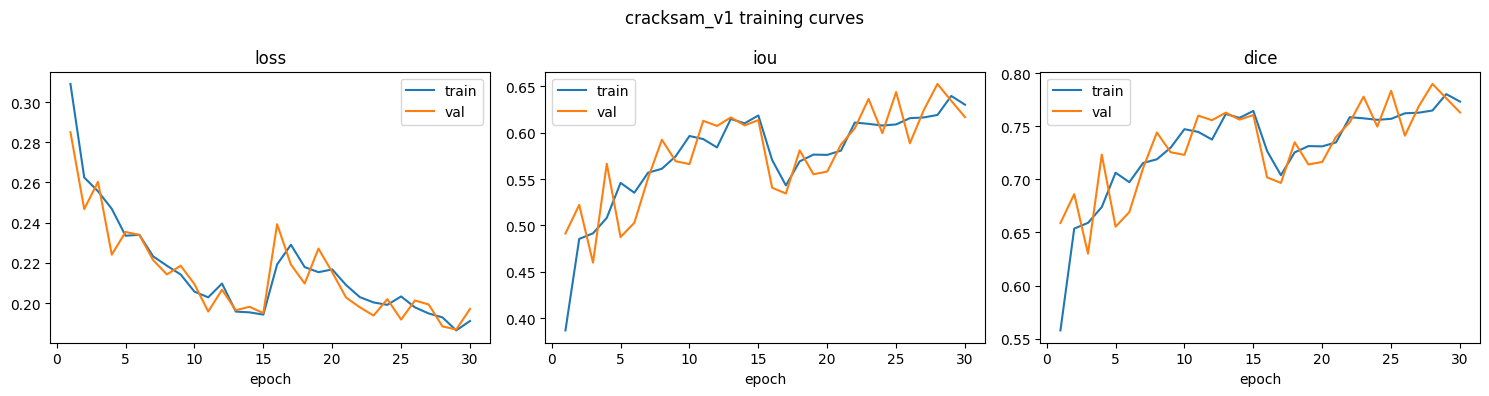

In [ ]:
# Training curves

import matplotlib.pyplot as plt

epochs_ran = range(1, len(history["train"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["loss", "iou", "dice"]):
    ax.plot(epochs_ran, [m[metric] for m in history["train"]], label="train")
    ax.plot(epochs_ran, [m[metric] for m in history["val"]], label="val")
    ax.set_title(metric)
    ax.set_xlabel("epoch")
    ax.legend()

plt.suptitle(f"{RUN_NAME} training curves")
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/training_curves.png", dpi=100)
plt.show()

## Evaluation 

In [ ]:
# Test evaluation (load best checkpoint)

ckpt = torch.load(f"{CKPT_DIR}/best.pth", map_location=device, weights_only=False)
sam_model.load_state_dict(ckpt["state_dict"])
best_val = ckpt.get("metrics", {})
best_epoch = ckpt.get("epoch", 0)
print(f"Best checkpoint  epoch={best_epoch}  val_iou={best_val['iou']:.4f}")

sam_model.eval()
test_tracker = MetricTracker()

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing", ncols=80):
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)
        points = batch["points"].to(device)
        point_labels = batch["point_labels"].to(device)

        logits = sam_forward(sam_model, images, points, point_labels, IMAGE_SIZE)
        test_tracker.update(logits, masks)


test_metrics = test_tracker.compute()
print(f"\nTest results — {RUN_NAME}")
for k, v in test_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

Best checkpoint  epoch=28  val_iou=0.6526


Testing: 100%|██████████████████████████████████| 52/52 [01:13<00:00,  1.41s/it]


Test results — cracksam_v1
  loss        : 0.0000
  iou         : 0.6168
  dice        : 0.7630


In [ ]:
# Per-class test results

sam_model.eval()
per_class = defaultdict(lambda: {"iou": [], "dice": []})

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)
        points = batch["points"].to(device)
        point_labels = batch["point_labels"].to(device)
        prompts = batch["prompt"]

        logits = sam_forward(sam_model, images, points, point_labels, IMAGE_SIZE)
        pred = (torch.sigmoid(logits).squeeze(1) >= 0.5).float()

        for i, prompt in enumerate(prompts):
            p, gt = pred[i], masks[i].squeeze()
            inter = (p * gt).sum()
            iou = (inter / ((p + gt).clamp(0, 1).sum() + 1e-6)).item()
            dice = (2 * inter / (p.sum() + gt.sum() + 1e-6)).item()
            key = "crack" if "crack" in prompt.lower() else "drywall"
            per_class[key]["iou"].append(iou)
            per_class[key]["dice"].append(dice)

print("Per-class test results:")
for cls, vals in per_class.items():
    print(
        f"  {cls:10s}  IoU={np.mean(vals['iou']):.4f}  "
        f"Dice={np.mean(vals['dice']):.4f}  n={len(vals['iou'])}"
    )

Per-class test results:
  drywall     IoU=0.6527  Dice=0.7821  n=38
  crack       IoU=0.5856  Dice=0.7221  n=168


Crack   prompts : ['segment crack', 'segment crack', 'segment crack']
Drywall prompts : ['segment taping area', 'segment taping area', 'segment taping area']


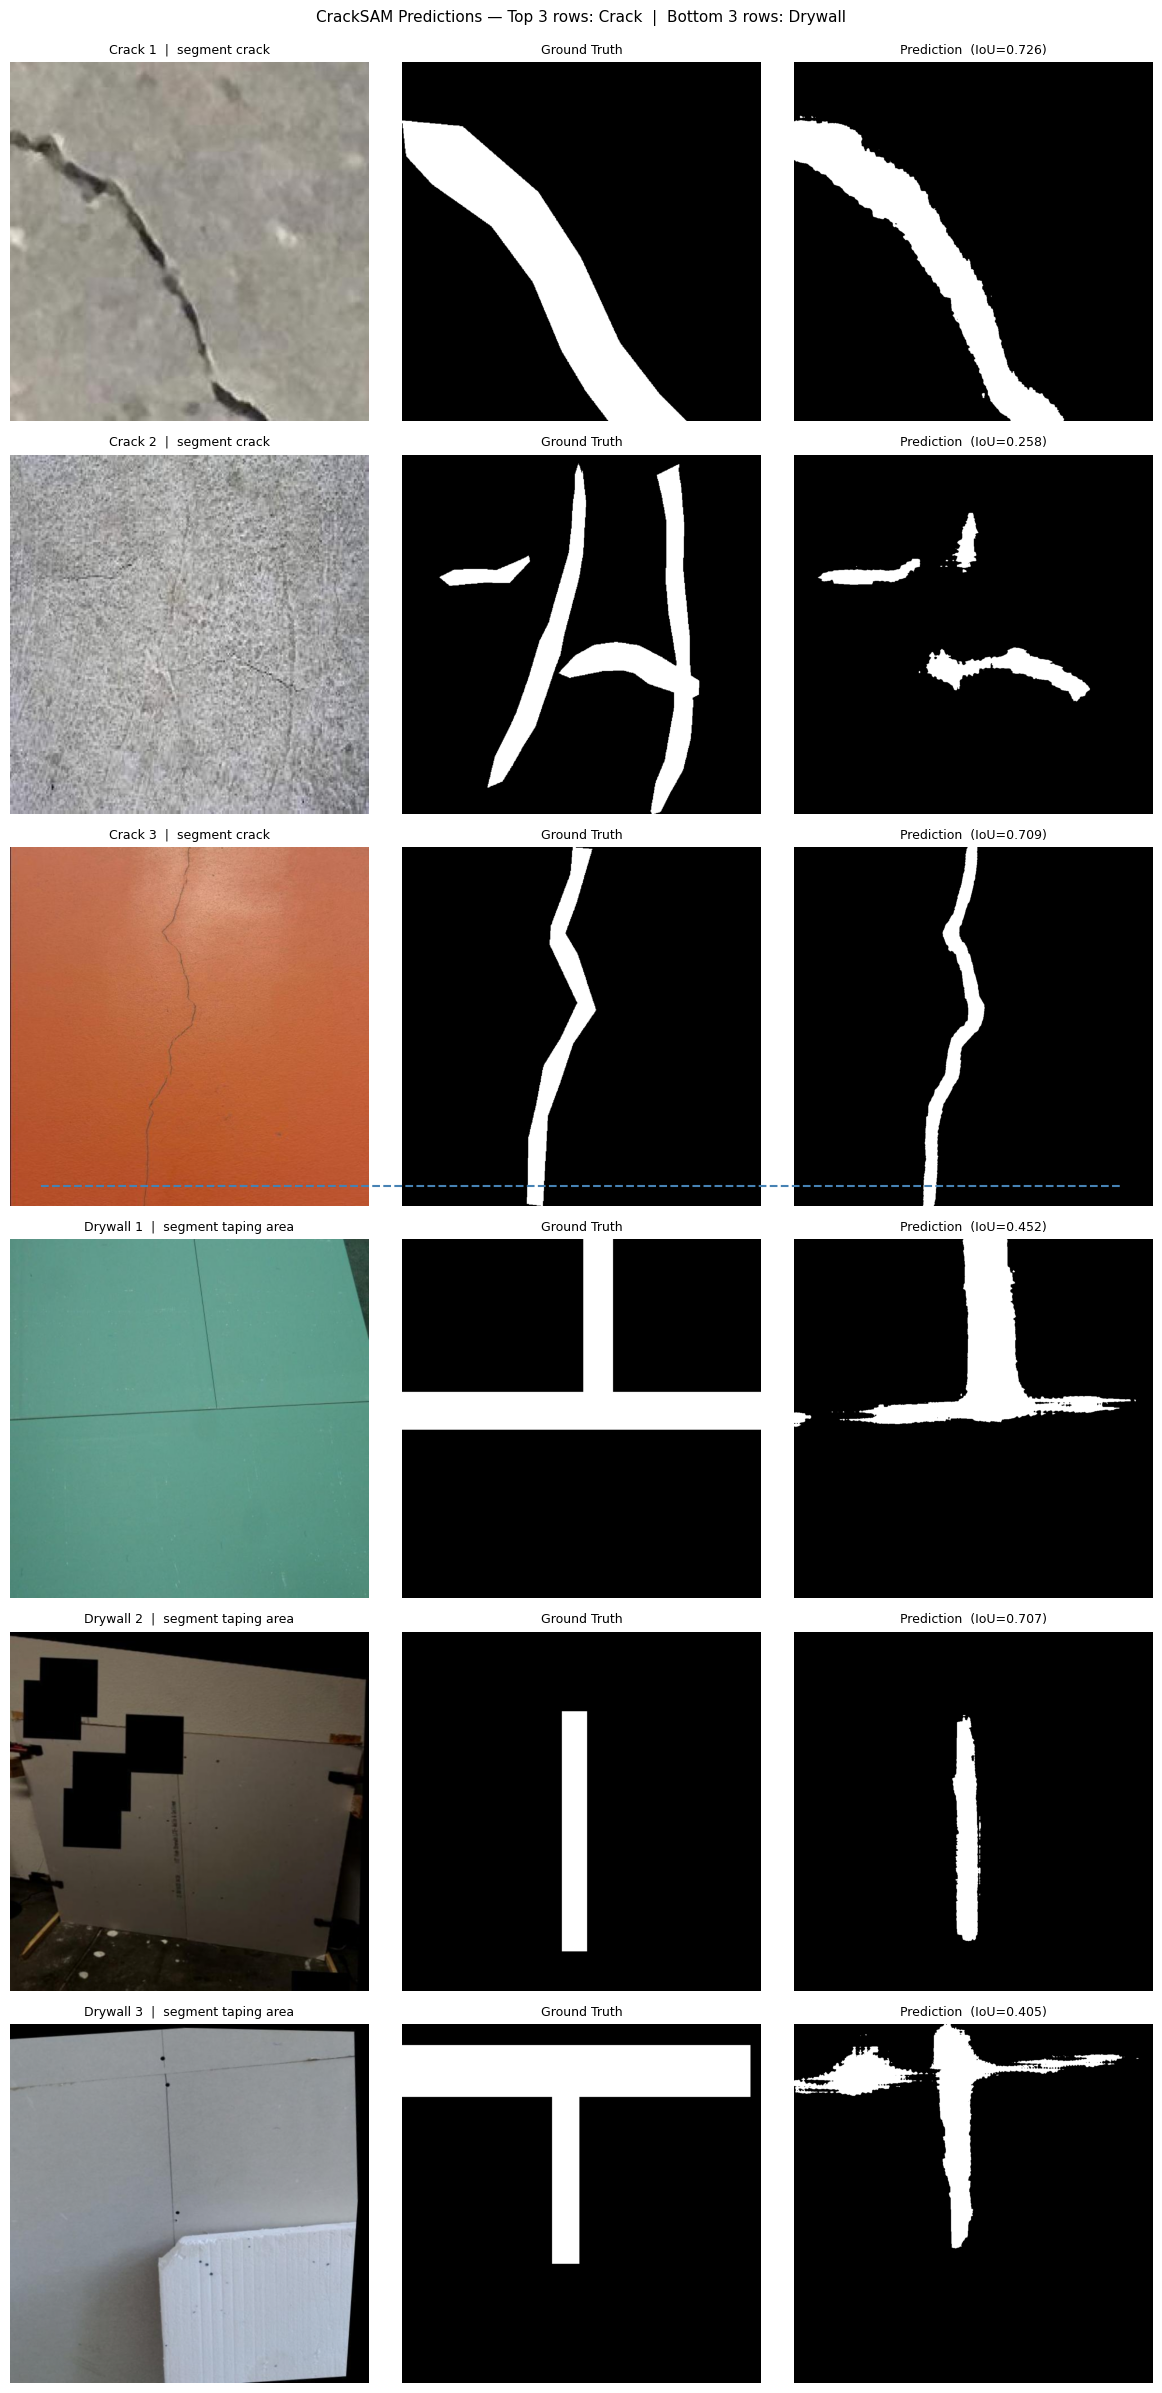

Saved → /kaggle/working/visualisations/cracksam_v1/sample_predictions.png


In [ ]:
# Visudalization
sam_model.eval()

crack_samples = []
drywall_samples = []

with torch.no_grad():
    for batch in test_loader:
        prompts = batch["prompt"]

        for idx, prompt in enumerate(prompts):
            cls = "crack" if "crack" in prompt.lower() else "drywall"

            sample = {
                "image": batch["image"][idx : idx + 1],
                "mask": batch["mask"][idx : idx + 1],
                "points": batch["points"][idx : idx + 1],
                "point_labels": batch["point_labels"][idx : idx + 1],
                "prompt": [prompt],
            }

            if cls == "crack" and len(crack_samples) < 3:
                crack_samples.append(sample)
            if cls == "drywall" and len(drywall_samples) < 3:
                drywall_samples.append(sample)

        if len(crack_samples) == 3 and len(drywall_samples) == 3:
            break

print(f"Crack   prompts : {[s['prompt'][0] for s in crack_samples]}")
print(f"Drywall prompts : {[s['prompt'][0] for s in drywall_samples]}")


all_samples = crack_samples + drywall_samples  # 3 crack first, then 3 drywall

all_images = torch.cat([s["image"] for s in all_samples], dim=0)
all_masks = torch.cat([s["mask"] for s in all_samples], dim=0)
all_prompts = [s["prompt"][0] for s in all_samples]

all_logits_list = []
with torch.no_grad():
    for s in all_samples:
        logits = sam_forward(
            sam_model,
            s["image"].to(device),
            s["points"].to(device),
            s["point_labels"].to(device),
            IMAGE_SIZE,
        ).cpu()
        all_logits_list.append(logits)

all_logits = torch.cat(all_logits_list, dim=0)


mean = torch.tensor([123.675, 116.28, 103.53]).view(3, 1, 1)
std = torch.tensor([58.395, 57.12, 57.375]).view(3, 1, 1)
preds = (torch.sigmoid(all_logits) >= 0.5).float()

fig, axes = plt.subplots(6, 3, figsize=(12, 24))

labels = ["Crack 1", "Crack 2", "Crack 3", "Drywall 1", "Drywall 2", "Drywall 3"]

for i in range(6):
    img = all_images[i].cpu() * std + mean
    img = img.permute(1, 2, 0).numpy().clip(0, 255).astype(np.uint8)
    gt = all_masks[i].cpu().squeeze().numpy()
    pr = preds[i].cpu().squeeze().numpy()

    # compute IoU for this single image
    inter = float((preds[i].squeeze() * all_masks[i].cpu().squeeze()).sum())
    union = float(
        ((preds[i].squeeze() + all_masks[i].cpu().squeeze()).clamp(0, 1)).sum()
    )
    iou = inter / (union + 1e-6)

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"{labels[i]}  |  {all_prompts[i]}", fontsize=9)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(gt, cmap="gray")
    axes[i, 1].set_title("Ground Truth", fontsize=9)
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pr, cmap="gray")
    axes[i, 2].set_title(f"Prediction  (IoU={iou:.3f})", fontsize=9)
    axes[i, 2].axis("off")

fig.add_artist(
    plt.Line2D(
        [0.05, 0.95],
        [0.505, 0.505],
        transform=fig.transFigure,
        color="steelblue",
        linewidth=1.5,
        linestyle="--",
    )
)

plt.suptitle(
    "CrackSAM Predictions — Top 3 rows: Crack  |  Bottom 3 rows: Drywall",
    fontsize=11,
    y=0.995,
)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/sample_predictions.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved → {VIZ_DIR}/sample_predictions.png")

In [ ]:
# Save predictions + morphological cleanup


sam_model.eval()

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Saving preds", ncols=80):
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)
        points = batch["points"].to(device)
        point_labels = batch["point_labels"].to(device)
        stems = batch["stem"]
        prompts = batch["prompt"]

        logits = sam_forward(sam_model, images, points, point_labels, IMAGE_SIZE)
        pred_bin = (torch.sigmoid(logits).squeeze(1) >= 0.5).cpu().numpy()

        for i, (stem, prompt) in enumerate(zip(stems, prompts)):
            ds_name = "drywall" if stem.startswith("drywall") else "cracks"
            src_path = Path(PROCESSED_ROOT) / ds_name / "images" / f"{stem}.jpg"
            src_img = cv2.imread(str(src_path))
            h, w = src_img.shape[:2]

            mask_out = cv2.resize(
                pred_bin[i].astype(np.uint8) * 255,
                (w, h),
                interpolation=cv2.INTER_NEAREST,
            )

            # morphological cleanup (3x3 for thin cracks)
            k = np.ones((3, 3), np.uint8)
            mask_out = cv2.morphologyEx(mask_out, cv2.MORPH_OPEN, k)
            mask_out = cv2.morphologyEx(mask_out, cv2.MORPH_CLOSE, k)

            slug = prompt.replace(" ", "_")
            cv2.imwrite(str(Path(PRED_DIR) / f"{stem}__{slug}.png"), mask_out)

print(f"Predictions → {PRED_DIR}")

Saving preds: 100%|█████████████████████████████| 52/52 [01:14<00:00,  1.43s/it]

Predictions → /kaggle/working/predictions/cracksam_v1


In [ ]:
# Inference speed & model size

import os
import numpy as np
import torch

sam_model.eval()
dummy_batch = next(iter(test_loader))
dummy_img = dummy_batch["image"][:1].to(device)
dummy_pts = dummy_batch["points"][:1].to(device)
dummy_lbl = dummy_batch["point_labels"][:1].to(device)

# warmup
for _ in range(5):
    with torch.no_grad():
        _ = sam_forward(sam_model, dummy_img, dummy_pts, dummy_lbl, IMAGE_SIZE)

starter = torch.cuda.Event(enable_timing=True)
ender = torch.cuda.Event(enable_timing=True)
times = []

with torch.no_grad():
    for _ in range(30):
        starter.record()
        _ = sam_forward(sam_model, dummy_img, dummy_pts, dummy_lbl, IMAGE_SIZE)
        ender.record()
        torch.cuda.synchronize()
        times.append(starter.elapsed_time(ender))

ckpt_mb = os.path.getsize(f"{CKPT_DIR}/best.pth") / 1024 / 1024
total_params = sum(p.numel() for p in sam_model.parameters())
lora_n = sum(p.numel() for p in lora_params)


decoder_module = (
    sam_model.sam_mask_decoder
    if hasattr(sam_model, "sam_mask_decoder")
    else sam_model.mask_decoder
)
decoder_n = sum(p.numel() for p in decoder_module.parameters())

print(f"Inference    avg={np.mean(times):.1f}ms  std={np.std(times):.1f}ms")
print(
    f"Params       total={total_params / 1e6:.2f}M  lora={lora_n / 1e3:.1f}K  decoder={decoder_n / 1e6:.2f}M"
)
print(f"Checkpoint   {ckpt_mb:.1f} MB")

Inference    avg=330.8ms  std=4.1ms
Params       total=81.89M  lora=1057.3K  decoder=4.22M
Checkpoint   312.6 MB


In [ ]:
# Save final results JSON + zip

import shutil, json as _json

results = {
    RUN_NAME: {
        "val": best_val,
        "test": test_metrics,
        "per_class": {
            cls: {
                "iou": float(np.mean(vals["iou"])),
                "dice": float(np.mean(vals["dice"])),
                "n": len(vals["iou"]),
            }
            for cls, vals in per_class.items()
        },
        "inference_ms": float(np.mean(times)),
        "model_info": {
            "backbone": "SAM2 Hiera-B+" if SAM_VERSION == 2 else "SAM ViT-B",
            "lora_rank": LORA_RANK,
            "lora_params": int(lora_n),
            "decoder_params": int(decoder_n),
            "total_params": int(total_params),
            "ckpt_mb": round(ckpt_mb, 1),
        },
    }
}

with open(f"{METRICS_DIR}/results_{RUN_NAME}.json", "w") as f:
    _json.dump(results, f, indent=2)

print(_json.dumps(results, indent=2))

shutil.make_archive(f"/kaggle/working/{RUN_NAME}_results", "zip", "/kaggle/working")
print(f"\nDownload {RUN_NAME}_results.zip from the Output panel →")

{
  "cracksam_v1": {
    "val": {
      "loss": 0.18839127994051166,
      "iou": 0.6526056874413935,
      "dice": 0.7897899570366048
    },
    "test": {
      "loss": 0.0,
      "iou": 0.6167691180752819,
      "dice": 0.7629649913273061
    },
    "per_class": {
      "drywall": {
        "iou": 0.6526500919931814,
        "dice": 0.7820836242876554,
        "n": 38
      },
      "crack": {
        "iou": 0.585561230512602,
        "dice": 0.7220669365709736,
        "n": 168
      }
    },
    "inference_ms": 330.76031595865885,
    "model_info": {
      "backbone": "SAM2 Hiera-B+",
      "lora_rank": 16,
      "lora_params": 1057280,
      "decoder_params": 4215109,
      "total_params": 81890946,
      "ckpt_mb": 312.6
    }
  }
}

Download cracksam_v1_results.zip from the Output panel →


## Failure Cases 

In [ ]:
# per-image IoU on the full test set - SAM2
sam_model.eval()
per_image_results = []

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device)
        points = batch["points"].to(device)
        point_labels = batch["point_labels"].to(device)
        masks = batch["mask"]
        prompts = batch["prompt"]
        stems = batch["stem"]

        logits = sam_forward(sam_model, images, points, point_labels, IMAGE_SIZE).cpu()
        preds = (torch.sigmoid(logits).squeeze(1) >= 0.5).float()

        for i in range(len(stems)):
            pred = preds[i]
            gt = masks[i].squeeze()

            inter = float((pred * gt).sum())
            union = float(((pred + gt).clamp(0, 1)).sum())
            iou = inter / (union + 1e-6)
            fp_ratio = float(pred.sum()) / (float(gt.sum()) + 1e-6)

            per_image_results.append(
                {
                    "stem": stems[i],
                    "prompt": prompts[i],
                    "iou": round(iou, 4),
                    "pred_px": int(pred.sum()),
                    "gt_px": int(gt.sum()),
                    "fp_ratio": round(fp_ratio, 2),
                }
            )

per_image_results.sort(key=lambda x: x["iou"])

print("── 10 worst predictions ─────────────────────────────")
for r in per_image_results[:10]:
    print(
        f"  IoU={r['iou']:.3f}  pred_px={r['pred_px']:5d}  "
        f"gt_px={r['gt_px']:5d}  fp_ratio={r['fp_ratio']:.1f}  "
        f"{r['prompt']:<25}  {r['stem']}"
    )

print("\n── 5 best predictions ───────────────────────────────")
for r in per_image_results[-5:]:
    print(f"  IoU={r['iou']:.3f}  {r['prompt']:<25}  {r['stem']}")

── 10 worst predictions ─────────────────────────────
  IoU=0.038  pred_px=11523  gt_px=  436  fp_ratio=26.4  segment crack              cracks_00547
  IoU=0.147  pred_px=17553  gt_px= 3207  fp_ratio=5.5  segment crack              cracks_00645
  IoU=0.168  pred_px=40361  gt_px= 6769  fp_ratio=6.0  segment crack              cracks_00199
  IoU=0.182  pred_px=41222  gt_px=34646  fp_ratio=1.2  segment crack              cracks_00553
  IoU=0.200  pred_px=11684  gt_px= 2414  fp_ratio=4.8  segment crack              cracks_00741
  IoU=0.207  pred_px=16695  gt_px= 5151  fp_ratio=3.2  segment crack              cracks_00210
  IoU=0.214  pred_px=36385  gt_px=135639  fp_ratio=0.3  segment crack              cracks_00501
  IoU=0.263  pred_px=21310  gt_px= 5600  fp_ratio=3.8  segment crack              cracks_00614
  IoU=0.265  pred_px=23753  gt_px= 6291  fp_ratio=3.8  segment crack              cracks_00115
  IoU=0.286  pred_px=42258  gt_px=14096  fp_ratio=3.0  segment crack              cracks_

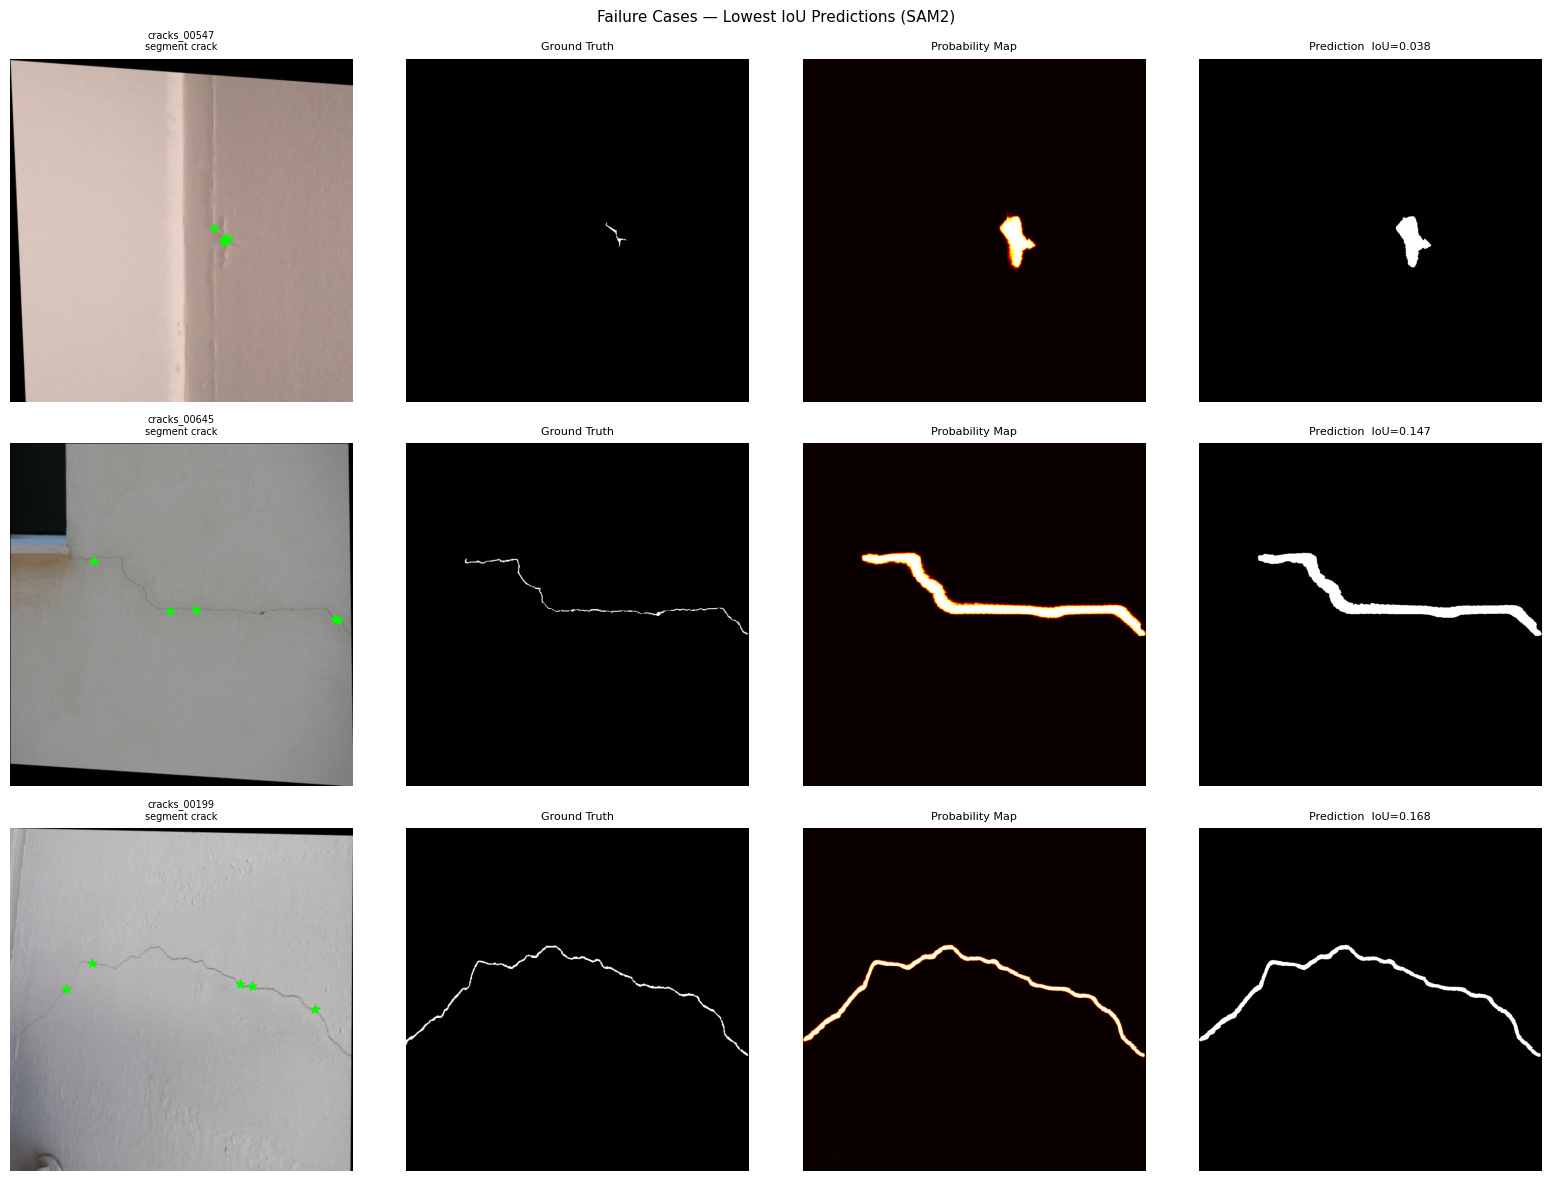

Saved → /kaggle/working/visualisations/cracksam_v1/failure_cases.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def show_failures_sam(worst_results, processed_root, device, n=3, threshold=0.5):
    sam_model.eval()

    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    for i, r in enumerate(worst_results[:n]):
        stem = r["stem"]
        prompt = r["prompt"]
        ds = "drywall" if stem.startswith("drywall") else "cracks"

        img_path = Path(processed_root) / ds / "images" / f"{stem}.jpg"
        mask_path = Path(processed_root) / ds / "masks" / f"{stem}.png"

        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        H, W = IMAGE_SIZE
        img_resized = cv2.resize(img, (W, H))
        mask_resized = cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST)

        fg_pixels = np.argwhere(mask_resized > 127)
        if len(fg_pixels) >= 5:
            chosen = fg_pixels[np.random.choice(len(fg_pixels), 5, replace=False)]
        elif len(fg_pixels) > 0:
            chosen = fg_pixels
        else:
            chosen = np.array([[H // 2, W // 2]])

        points_xy = chosen[:, [1, 0]].astype(np.float32)
        point_labels = np.ones(len(points_xy), dtype=np.int32)

        mean_px = np.array([123.675, 116.28, 103.53], dtype=np.float32)
        std_px = np.array([58.395, 57.12, 57.375], dtype=np.float32)
        img_norm = (img_resized.astype(np.float32) - mean_px) / std_px
        img_tensor = torch.from_numpy(img_norm).permute(2, 0, 1).unsqueeze(0).to(device)

        pts_tensor = torch.from_numpy(points_xy).unsqueeze(0).to(device)  # (1, N, 2)
        lbl_tensor = torch.from_numpy(point_labels).unsqueeze(0).to(device)  # (1, N)

        with torch.no_grad():
            logits = sam_forward(
                sam_model, img_tensor, pts_tensor, lbl_tensor, IMAGE_SIZE
            )
            prob = torch.sigmoid(logits).squeeze().cpu().numpy()
            pred = (prob >= threshold).astype(float)

        gt = mask_resized / 255.0

        axes[i, 0].imshow(img_resized)
        axes[i, 0].scatter(
            points_xy[:, 0],
            points_xy[:, 1],
            c="lime",
            s=40,
            marker="*",
            label="prompt points",
        )
        axes[i, 0].set_title(f"{stem}\n{prompt}", fontsize=7)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt, cmap="gray")
        axes[i, 1].set_title("Ground Truth", fontsize=8)
        axes[i, 1].axis("off")

        axes[i, 2].imshow(prob, cmap="hot", vmin=0, vmax=1)
        axes[i, 2].set_title("Probability Map", fontsize=8)
        axes[i, 2].axis("off")

        axes[i, 3].imshow(pred, cmap="gray")
        axes[i, 3].set_title(f"Prediction  IoU={r['iou']:.3f}", fontsize=8)
        axes[i, 3].axis("off")

    plt.suptitle("Failure Cases — Lowest IoU Predictions (SAM2)", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{VIZ_DIR}/failure_cases.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved → {VIZ_DIR}/failure_cases.png")


show_failures_sam(per_image_results, PROCESSED_ROOT, device, n=3)